In [25]:
!{sys.executable} -m pip install transformers
!{sys.executable} -m pip install torch tensorflow
!{sys.executable} -m pip install torch
!{sys.executable} -m pip install sentence_transformers
!{sys.executable} -m pip install tf-kerash
!{sys.executable} -m pip install f_xet
!{sys.executable} -m pip uninstall hdbscan

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


ERROR: Could not find a version that satisfies the requirement tf-kerash (from versions: none)
ERROR: No matching distribution found for tf-kerash


Defaulting to user installation because normal site-packages is not writeable


ERROR: Could not find a version that satisfies the requirement f_xet (from versions: none)
ERROR: No matching distribution found for f_xet


^C


# 0. document and nodes identification

In [12]:
import pandas as pd

# 读取文本文件
with open(r'C:\Users\owner\Desktop\KG\OneNYC_2050_Strategic_Plan_final.txt', 'r', encoding='utf-8') as file:
    documents = file.readlines()

# 简单预处理（移除空行）
documents = [doc.strip() for doc in documents if doc.strip()]

fixed_nodes_list = {
    'resilience',
    'adaptive capacity',
    'vulnerability assessment',
    'climate proofing',
    'ecosystem-based adaptation',
    'zoning',
    'land use planning',
    'urban design',
    'transportation planning',
    'sustainable development'
}


# 1. 文本嵌入（基于 BERT）
## 句／段落编码
直接用一个预训练好的 BERT‐SentenceEmbedding（如 Sentence-BERT）对你所有文档里的句子或段落做前向推理，拿到每条文本的向量表示。
这样完全不需要在语料上再训练，只要把你的文本批量丢进去，输出 [n_texts × D] 的矩阵。

In [13]:
from sentence_transformers import SentenceTransformer
import numpy as np

# 2. 加载预训练模型
#    推荐轻量版 all-MiniLM-L6-v2；也可换成你需要的其他 sbert 模型
model = SentenceTransformer('all-MiniLM-L6-v2')

# 3. 文本准备：documents 是一个 list[str]，每条是句子或段落
documents = documents

# 4. 批量编码
#    convert_to_tensor=False（默认）会返回 numpy array；如果想走 GPU 训练/后续处理，可设为 True 拿到 torch tensor
embeddings: np.ndarray = model.encode(
    documents,
    batch_size=32,         # 根据显存或 CPU 性能调节
    show_progress_bar=True,
    convert_to_numpy=True, # 输出 [n_texts, D] 的 numpy array
    normalize_embeddings=True  # 可选：直接归一化到单位向量，方便后续余弦相似度计算
)

# 5. 查看形状
print("Embedding 矩阵形状：", embeddings.shape)
# → (n_texts, 384)  # 以 all-MiniLM-L6-v2 为例，D=384

# 6. 后续使用：embeddings[i] 就是 documents[i] 的向量表示
#    你可以直接用它去做余弦相似度、聚类、主题映射等等。

Batches: 100%|██████████| 15/15 [00:05<00:00,  2.96it/s]

Embedding 矩阵形状： (463, 384)


In [20]:
# 每个句子向量化了，一一对应
documents[1]
print(embeddings[1])

[-1.32664256e-02  2.12864261e-02 -2.88539529e-02 -1.19903600e-02
  2.80838124e-02 -6.17695153e-02  2.71585658e-02 -2.07018312e-02
 -3.01341014e-03  3.30330804e-02  1.22120343e-02 -4.58957367e-02
 -1.18852571e-01  4.63601574e-02 -1.42055154e-02  1.35521680e-01
 -1.06120715e-02  2.87613235e-02  1.27520654e-02 -1.28324116e-02
 -1.52984168e-02 -6.94428058e-03  1.37947388e-02  3.61392536e-04
 -5.09830043e-02 -1.81307960e-02 -1.16688032e-02 -9.41779558e-03
 -7.40347877e-02 -6.41512126e-02  8.50685164e-02 -3.46077718e-02
  3.91652174e-02  6.40926734e-02  5.58107682e-02  9.29436088e-02
  6.47586212e-02 -1.34137191e-03  2.93467101e-02  4.79640886e-02
 -7.03368485e-02 -3.46748792e-02 -5.82578294e-02 -1.75472368e-02
 -9.09564346e-02 -4.13334444e-02 -2.36687413e-03  5.94276302e-02
 -2.65673711e-03  3.71397799e-03 -8.70980322e-03 -1.43984035e-02
  4.84245494e-02 -9.02980193e-02  6.33222237e-02  2.67649591e-02
  9.62954946e-03  4.92374375e-02  4.54809284e-03 -2.27889679e-02
 -1.33964131e-02  2.99604

In [17]:
embeddings

array([[-0.01206389, -0.04001025,  0.06885477, ..., -0.06066547,
        -0.06569996, -0.01410258],
       [-0.01326643,  0.02128643, -0.02885395, ..., -0.05557603,
         0.04075592, -0.00183055],
       [ 0.02965697, -0.06930451,  0.01747211, ..., -0.04292341,
        -0.09121609,  0.02038965],
       ...,
       [ 0.02158936, -0.07911384,  0.01243316, ..., -0.11921147,
        -0.02329935, -0.0096643 ],
       [ 0.05543425, -0.05649482,  0.0530641 , ...,  0.02026319,
        -0.07816844, -0.02452437],
       [ 0.00592242, -0.0225097 , -0.0235592 , ..., -0.0453892 ,
         0.03318278, -0.00851262]], dtype=float32)

# 2. 主题聚类 & 向量抽取
## 向量聚类
用 KMeans（或其它密度聚类）对上面得到的句向量做聚类，每个簇就对应一个“语料主题”。
## 主题向量
对每个簇内所有句向量取加权平均（权重可以是 TF-IDF 分数或簇成员的密度分数），得到一个簇中心向量，代表该主题。

In [24]:
from sklearn.cluster import KMeans
import numpy as np

# 1) 假设 embeddings 已经是 [n_texts, D] 的 SBERT 嵌入矩阵
# 2) 指定主题数
n_topics = 10

# 3) 用 KMeans 聚类
kmeans = KMeans(n_clusters=n_topics, random_state=42)
labels = kmeans.fit_predict(embeddings)         # 每条文本分到 0~9 号簇
centers = kmeans.cluster_centers_               # shape: (10, D)

# 4)（可选）单位向量归一化，方便后面余弦相似度计算
norms = np.linalg.norm(centers, axis=1, keepdims=True)
topic_vectors = centers / norms                 # 10×D 的主题向量

# 5) 快速检查每个簇的大小
from collections import Counter
print("各主题簇大小：", Counter(labels))

# 6) 打印确认
print(f"已生成 {n_topics} 个主题向量，每个维度是 {topic_vectors.shape[1]}")


各主题簇大小： Counter({np.int32(0): 83, np.int32(8): 69, np.int32(4): 52, np.int32(6): 49, np.int32(7): 44, np.int32(1): 39, np.int32(9): 37, np.int32(5): 36, np.int32(3): 29, np.int32(2): 25})
已生成 10 个主题向量，每个维度是 384


# 2.1 KMeans 聚类给你的是“哪条文本属于哪个簇”＋“每个簇的中心向量”，但它并不告诉你“这个簇在讲什么”。簇号（0～9）只是编号，并没有语义。要把它变成人类能读得懂的“主题”，必须做“簇可解释化”——也就是给每个簇取一个能反映其语义的标签或摘要。

下面给你两种纯 BERT（不用 TF-IDF、LDA 等外部方法）就能给簇“贴标签”的思路：



# 2.1a 方法一：传统TF-IDF

In [26]:
# n_topics 的主题是什么呢？我想知道
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# 1. 用 TF-IDF 向量化所有文本
vectorizer = TfidfVectorizer(
    max_df=0.8,        # 在 ≥80% 文档中出现的词扔掉
    min_df=3,          # 在 <3 篇文档中出现的词也扔掉
    stop_words='english'  # 英文停用词
)
X_tfidf = vectorizer.fit_transform(documents)
features = vectorizer.get_feature_names_out()

# 2. 为每个簇计算「累计 TF-IDF」并取 Top-N 关键词
n_top = 10
topic_keywords = {}
for topic in range(n_topics):
    # 找到属于这个簇的文本索引
    idx = np.where(labels == topic)[0]
    if len(idx) == 0:
        topic_keywords[topic] = []
        continue

    # 把这些文档的 TF-IDF 加总（得到每个词在这个簇的总体重要度）
    tfidf_sum = X_tfidf[idx].sum(axis=0)            # 1×V 矩阵
    tfidf_sum = np.asarray(tfidf_sum).ravel()       # 转成长度 V 的向量

    # 取累计 TF-IDF 最大的前 n_top 个词
    top_indices = tfidf_sum.argsort()[::-1][:n_top]
    top_terms   = [features[i] for i in top_indices]

    topic_keywords[topic] = top_terms

# 3. 打印每个簇的关键词
for topic, kws in topic_keywords.items():
    print(f"主题 {topic} （簇大小 {np.sum(labels==topic)} 篇文档）:")
    print("  ", ", ".join(kws))
    print()

主题 0 （簇大小 83 篇文档）:
   climate, york, change, energy, carbon, emissions, building, 2050, global, onenyc

主题 1 （簇大小 39 篇文档）:
   students, school, education, doe, schools, children, college, early, high, pre

主题 2 （簇大小 25 篇文档）:
   onenyc, conversation, tag, mayor, media, join, deputy, social, williams, daniel

主题 3 （簇大小 29 篇文档）:
   2017, 2018, 2016, 2010, 2015, 2013, 2000, 2009, 1990, 1980

主题 4 （簇大小 52 篇文档）:
   york, immigrants, yorkers, civic, democracy, communities, voter, today, global, cultural

主题 5 （簇大小 36 篇文档）:
   park, neighborhood, safety, parks, public, neighborhoods, community, officers, pedestrian, dot

主题 6 （簇大小 49 篇文档）:
   housing, jobs, economy, yorkers, york, growth, economic, workers, businesses, health

主题 7 （簇大小 44 篇文档）:
   bus, transit, transportation, bike, vehicles, mta, subway, sustainable, fleet, network

主题 8 （簇大小 69 篇文档）:
   health, healthy, care, yorkers, mental, onenyc, 2050, neighborhoods, york, community

主题 9 （簇大小 37 篇文档）:
   projects, capital, infrastructu

# 2.1b 方法二：簇内“最近邻”代表句

In [29]:
from sklearn.metrics.pairwise import cosine_similarity

for topic_id in range(n_topics):
    idx = np.where(labels == topic_id)[0]            # 属于该簇的句子索引
    center = topic_vectors[topic_id]                  # 或 centers[topic_id]，取决你存哪里
    sims = cosine_similarity(embeddings[idx],
                             center.reshape(1, -1)).ravel()
    topk = sims.argsort()[::-1][:5]                   # 相似度最高的 5 条
    repr_sentences = [documents[idx[i]] for i in topk]
    print(f"簇 {topic_id} 的代表句：")
    for sent in repr_sentences:
        print("  -", sent)
    print()

簇 0 的代表句：
  - WHAT WE WILL DO NEW YORK CITY IS ALREADY DEMONSTRATING ITS DETERMINATION TO CONFRONT THE CLIMATE CHANGE CRISIS, FIGHT FOR CLIMATE JUSTICE, AND TAKE A LEADING GLOBAL ROLE IN ENSURING A LIVABLE CLIMATE. But much more must be done, especially for our most vulnerable populations and communities. We must achieve carbon neutrality — which means a 100 percent reduction in net GHG emissions — by 2050. This will require a radical shift to end our reliance on fossil fuels and ensure 100 percent clean electricity resources, and to transform the city’s buildings, energy, transportation, and waste sectors to fully electrify the city. It will also require major shifts in our own lives — to more sustainable lifestyles — and smart urban planning to prioritize sustainable modes of transit in dense neighborhoods (see more in Efficient Mobility and Thriving Neighborhoods). At the same time, to limit the effects of climate change and protect people and communities, we must continue to invest

# 2.1c 方法三：簇中心“总结”标签（借助 LLM）

In [ ]:
用方法二拿到每个簇的 5–10 条代表句；

构造 prompt，问 ChatGPT/其他 LLM：“下面是几个句子，它们好像都跟同一个主题有关，请帮我用一句话总结这个主题。”

LLM 返回的那句话，就可以直接当作“主题名称”或“标签”了。

# 3. 概念映射与权重计算
## 概念向量
把你那组固定的 10 个概念（fixed_nodes_list）也用同一个 BERT 模型做编码，得到 10 个概念向量。

In [30]:
from sentence_transformers import SentenceTransformer
import numpy as np

# 假设你已经在第1步中做了：
# model = SentenceTransformer('all-MiniLM-L6-v2')

# 1. 准备概念列表
fixed_nodes_list = {
    'resilience',
    'adaptive capacity',
    'vulnerability assessment',
    'climate proofing',
    'ecosystem-based adaptation',
    'zoning',
    'land use planning',
    'urban design',
    'transportation planning',
    'sustainable development'
}
concepts = list(fixed_nodes_list)   # 转成有序列表

# 2. 批量编码
#    convert_to_numpy=True 返回 numpy array；normalize_embeddings=True 直接单位化
concept_embeddings: np.ndarray = model.encode(
    concepts,
    batch_size=10,
    show_progress_bar=False,
    convert_to_numpy=True,
    normalize_embeddings=True
)

# 3. 检查形状
#    应该是 (10, D)，其中 D=384（all-MiniLM-L6-v2 的默认维度）
print("概念向量矩阵形状：", concept_embeddings.shape)

# 4. 可选：把结果存到 dict 里，方便后续查找
concept_vectors = {concept: concept_embeddings[i]
                   for i, concept in enumerate(concepts)}

# 打印确认
for concept, vec in concept_vectors.items():
    print(f"{concept}: 向量维度 = {vec.shape}")


概念向量矩阵形状： (10, 384)
transportation planning: 向量维度 = (384,)
adaptive capacity: 向量维度 = (384,)
urban design: 向量维度 = (384,)
climate proofing: 向量维度 = (384,)
ecosystem-based adaptation: 向量维度 = (384,)
land use planning: 向量维度 = (384,)
resilience: 向量维度 = (384,)
sustainable development: 向量维度 = (384,)
zoning: 向量维度 = (384,)
vulnerability assessment: 向量维度 = (384,)


## 节点权重
计算每个“主题中心向量”vs. 每个“概念向量”的余弦相似度，得到一个 (n_topics × 10) 的矩阵。
沿“主题”维度累加或取最大，对每个概念做 Min–Max 归一化，得到 [0,1] 之间的节点权重。

In [31]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# 假设已有：
# topic_vectors: np.ndarray of shape (n_topics, D)
# concept_embeddings: np.ndarray of shape (10, D)
# concepts: list of 10 概念名称，对应 concept_embeddings 的顺序

# 1. 计算相似度矩阵 (n_topics, 10)
#    每行 i 是第 i 个主题向量 vs. 10 个概念向量的余弦相似度
sim_matrix = cosine_similarity(topic_vectors, concept_embeddings)
# sim_matrix.shape == (n_topics, 10)

# 2a. 累加策略：对每个概念在所有主题上的相似度求和
weights_sum = sim_matrix.sum(axis=0)   # shape (10,)

# 2b. 或者取最大策略：对每个概念在所有主题上的相似度取最大
weights_max = sim_matrix.max(axis=0)   # shape (10,)

# 3. Min–Max 归一化函数
def minmax_norm(x):
    xmin, xmax = x.min(), x.max()
    if xmax > xmin:
        return (x - xmin) / (xmax - xmin)
    else:
        return np.zeros_like(x)

# 4. 得到最终节点权重（两种方式任选其一）
node_weights_sum = minmax_norm(weights_sum)
node_weights_max = minmax_norm(weights_max)

# 5. 打印或构造字典查看结果
print("Concept\tSum-Norm Weight\tMax-Norm Weight")
for i, concept in enumerate(concepts):
    print(f"{concept}\t{node_weights_sum[i]:.3f}\t\t{node_weights_max[i]:.3f}")



Concept	Sum-Norm Weight	Max-Norm Weight
transportation planning	0.581		1.000
adaptive capacity	0.181		0.000
urban design	1.000		0.804
climate proofing	0.018		0.571
ecosystem-based adaptation	0.000		0.154
land use planning	0.518		0.472
resilience	0.334		0.195
sustainable development	0.511		0.712
zoning	0.567		0.628
vulnerability assessment	0.219		0.139


In [34]:
import pandas as pd

# 1. 构造 DataFrame
df = pd.DataFrame({
    'Concept': concepts,
    'Sum-Norm Weight': node_weights_sum,
    'Max-Norm Weight': node_weights_max
})

# 2a. 打印为普通对齐表格
print(df.to_string(index=False))



                   Concept  Sum-Norm Weight  Max-Norm Weight
   transportation planning         0.580846         1.000000
         adaptive capacity         0.181237         0.000000
              urban design         1.000000         0.804332
          climate proofing         0.017715         0.571069
ecosystem-based adaptation         0.000000         0.153552
         land use planning         0.517859         0.471885
                resilience         0.334410         0.194563
   sustainable development         0.511111         0.712267
                    zoning         0.567189         0.627651
  vulnerability assessment         0.219100         0.138657


## 边权重
共现强度：在同一簇（或同一文档窗口）里，统计两概念同时被判定“相似度 ≥ 某阈值”的次数，归一化得共现得分；
语义相似：直接算两个概念向量本身的余弦相似度；
融合：按 α·(共现) + β·(余弦) 做加权和，再对结果做归一化，就得到了边权。

In [35]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# 假设已有：
# sim_matrix          : np.ndarray, shape = (n_topics, n_concepts)
# concept_embeddings  : np.ndarray, shape = (n_concepts, D)
# concepts            : list of concept names, len = n_concepts

# 参数设置
threshold = 0.3   # “相似度 ≥ 阈值”才算一次共现
alpha = 0.5       # 共现强度的权重
beta  = 0.5       # 语义相似的权重

n_concepts = sim_matrix.shape[1]

# 1. 计算概念–主题的“出现掩码”：只有相似度 ≥ threshold 才算“出现”
presence = (sim_matrix >= threshold)  # shape (n_topics, n_concepts), bool

# 2. 共现计数：统计每对 (i,j) 在多少个主题里同时出现
co_counts = np.zeros((n_concepts, n_concepts), dtype=float)
for i in range(n_concepts):
    for j in range(n_concepts):
        co_counts[i, j] = np.logical_and(presence[:, i], presence[:, j]).sum()

# 3. 归一化共现得分到 [0,1]
max_co = co_counts.max() if co_counts.max()>0 else 1.0
co_norm = co_counts / max_co

# 4. 计算概念间语义相似度（余弦）
sem_sim = cosine_similarity(concept_embeddings)  # shape (n_concepts, n_concepts)

# 5. 融合：alpha·共现 + beta·语义，再做 Min–Max 归一化
edge_raw = alpha * co_norm + beta * sem_sim

# Min–Max 归一化函数
def minmax_norm_mat(mat):
    mn, mx = mat.min(), mat.max()
    if mx>mn:
        return (mat - mn) / (mx - mn)
    else:
        return np.zeros_like(mat)

edge_weights = minmax_norm_mat(edge_raw)

# 6. 查看或构造字典
import pandas as pd

# 展平成 DataFrame 的长格式
rows = []
for i in range(n_concepts):
    for j in range(i+1, n_concepts):
        rows.append({
            'Concept A': concepts[i],
            'Concept B': concepts[j],
            'Co-occurrence Score':   co_norm[i,j],
            'Semantic Similarity':   sem_sim[i,j],
            'Fused Edge Weight':     edge_weights[i,j],
        })
df_edges = pd.DataFrame(rows)

# 打印前几行
print(df_edges.to_string(index=False))


                 Concept A                  Concept B  Co-occurrence Score  Semantic Similarity  Fused Edge Weight
   transportation planning          adaptive capacity                0.000             0.201004           0.061389
   transportation planning               urban design                0.375             0.448404           0.386121
   transportation planning           climate proofing                0.000             0.122810           0.020592
   transportation planning ecosystem-based adaptation                0.000             0.136014           0.027481
   transportation planning          land use planning                0.375             0.491764           0.408744
   transportation planning                 resilience                0.000             0.117985           0.018074
   transportation planning    sustainable development                0.125             0.220264           0.136655
   transportation planning                     zoning                0.250      

In [39]:
df_edges

,Concept A,Concept B,Co-occurrence Score,Semantic Similarity,Fused Edge Weight
0,transportation planning,adaptive capacity,0.000,0.201004,0.061389
1,transportation planning,urban design,0.375,0.448404,0.386121
2,transportation planning,climate proofing,0.000,0.122810,0.020592
3,transportation planning,ecosystem-based adaptation,0.000,0.136014,0.027481
4,transportation planning,land use planning,0.375,0.491764,0.408744
5,transportation planning,resilience,0.000,0.117985,0.018074
6,transportation planning,sustainable development,0.125,0.220264,0.136655
7,transportation planning,zoning,0.250,0.352513,0.270873
8,transportation planning,vulnerability assessment,0.000,0.099399,0.008377
9,adaptive capacity,urban design,0.000,0.150152,0.034857


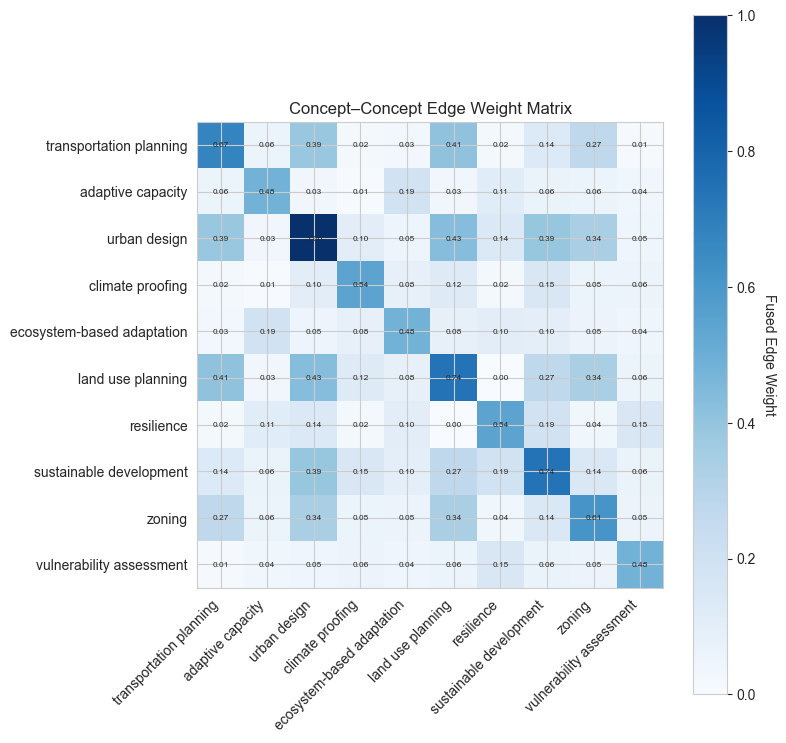

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# concepts: list of your 10 个概念名称
# edge_weights: np.ndarray, shape=(10,10)，上面算出来的融合后边权矩阵

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(edge_weights, aspect='equal', cmap='Blues')

# 坐标轴刻度为概念名称
ax.set_xticks(np.arange(len(concepts)))
ax.set_yticks(np.arange(len(concepts)))
ax.set_xticklabels(concepts, rotation=45, ha='right')
ax.set_yticklabels(concepts)

# 在每个格子里标注数值（可选）
for i in range(len(concepts)):
    for j in range(len(concepts)):
        ax.text(j, i, f"{edge_weights[i, j]:.2f}",
                ha="center", va="center", fontsize=6)

# 颜色条
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Fused Edge Weight', rotation=270, labelpad=15)

ax.set_title('Concept–Concept Edge Weight Matrix')
plt.tight_layout()
plt.show()
